# Quick synthetic to verify that the code works as intended

In [1]:
import pygmt
import numpy as np
import matplotlib.pyplot as plt
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd

import spherical as sph

## Forward modeling

Test the forward modeling functions and see if they make sense.

In [2]:
region = (-60, -30, -40, -10)
grid_coordinates = bd.grid_coordinates(region, spacing=10 / 60, non_dimensional_coords=200)
dipole = (-45, -20, -250e3)
# Regional field
inclination, declination = -30, 0
dipole_moment = hm.magnetic_angles_to_vec(1e17, inclination, declination)
magnetic_field = sph.dipole_magnetic_geodetic(grid_coordinates, dipole, dipole_moment)
total_field_anomaly = vd.make_xarray_grid(
    grid_coordinates,
    hm.total_field_anomaly(magnetic_field, inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

Make a map with PyGMT so we can visually inspect the anomaly. It should have a positive part to the North and negative to the South.

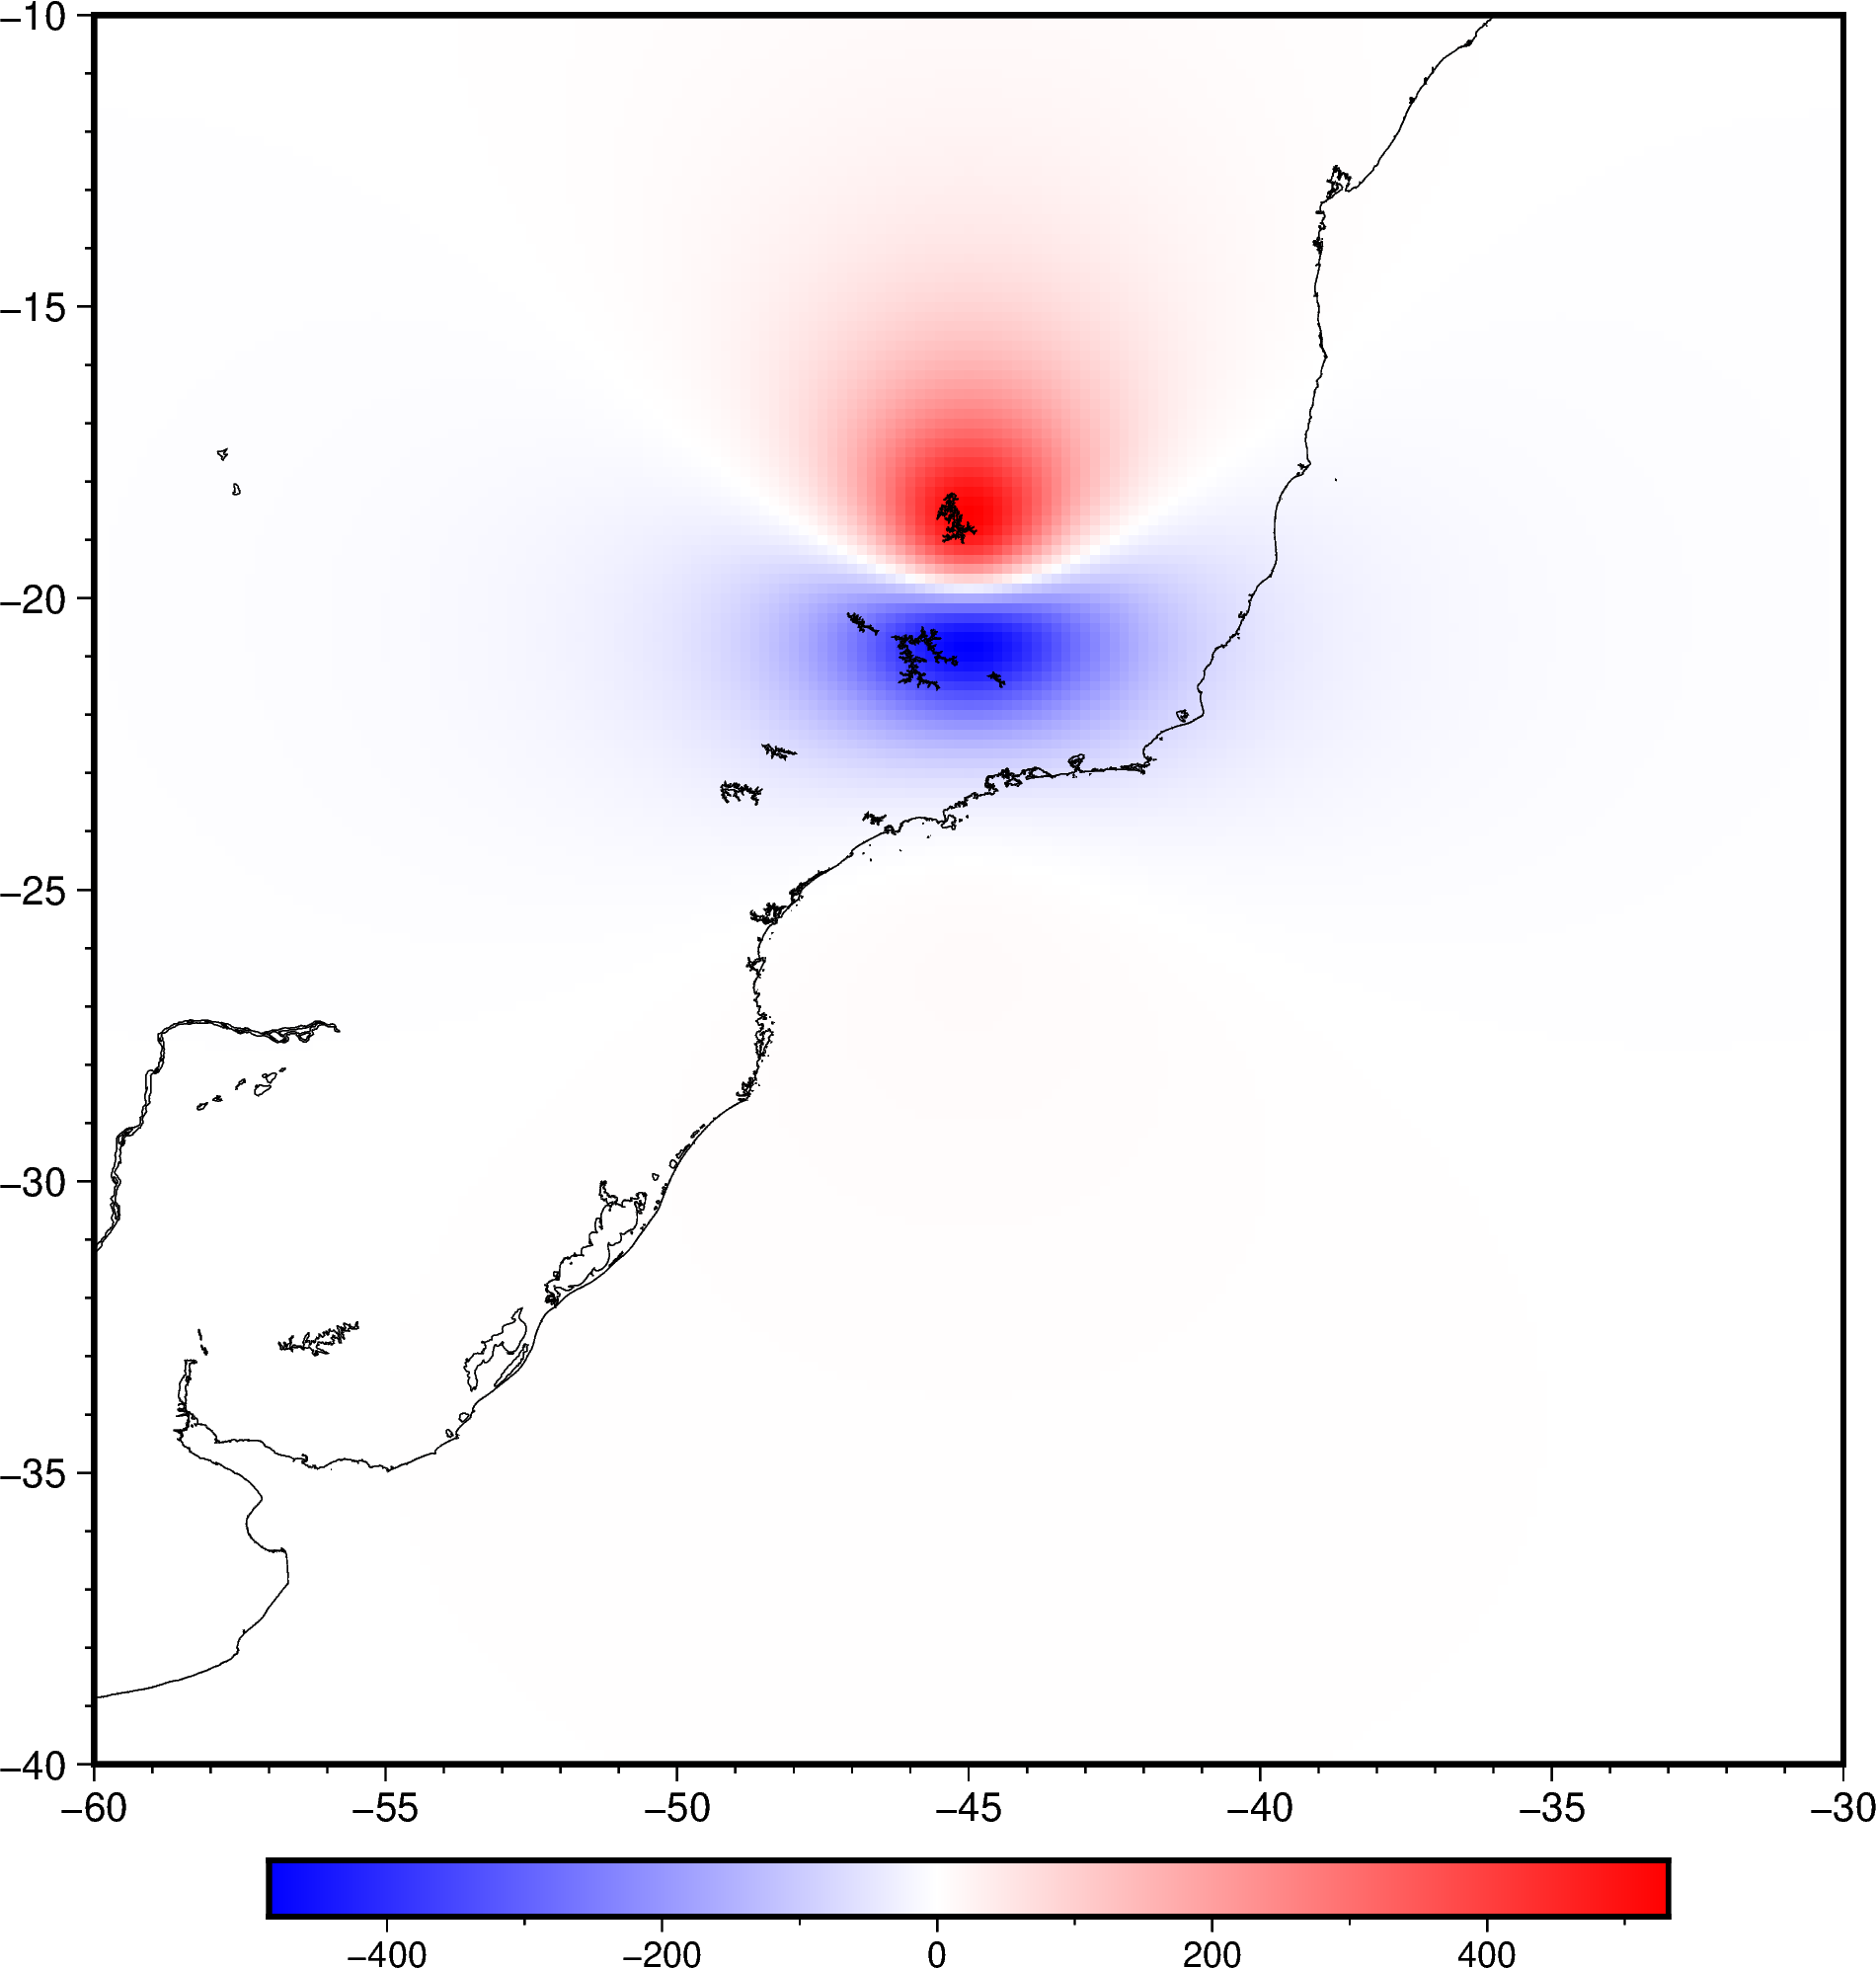

In [3]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

## Simple equivalent source inversion

Try recovering the dipole field with a simple single layer inversion.

In [4]:
coordinates = bd.random_coordinates(list(region) + [150, 300], 10000)
magnetic_field_obs = sph.dipole_magnetic_geodetic(coordinates, dipole, dipole_moment)
data = hm.total_field_anomaly(magnetic_field_obs, inclination, declination)
noise_level = 0.02 * vd.maxabs(data)
data += np.random.default_rng(42).normal(0, noise_level, data.shape)
print(noise_level, "nT")

10.365936853799964 nT


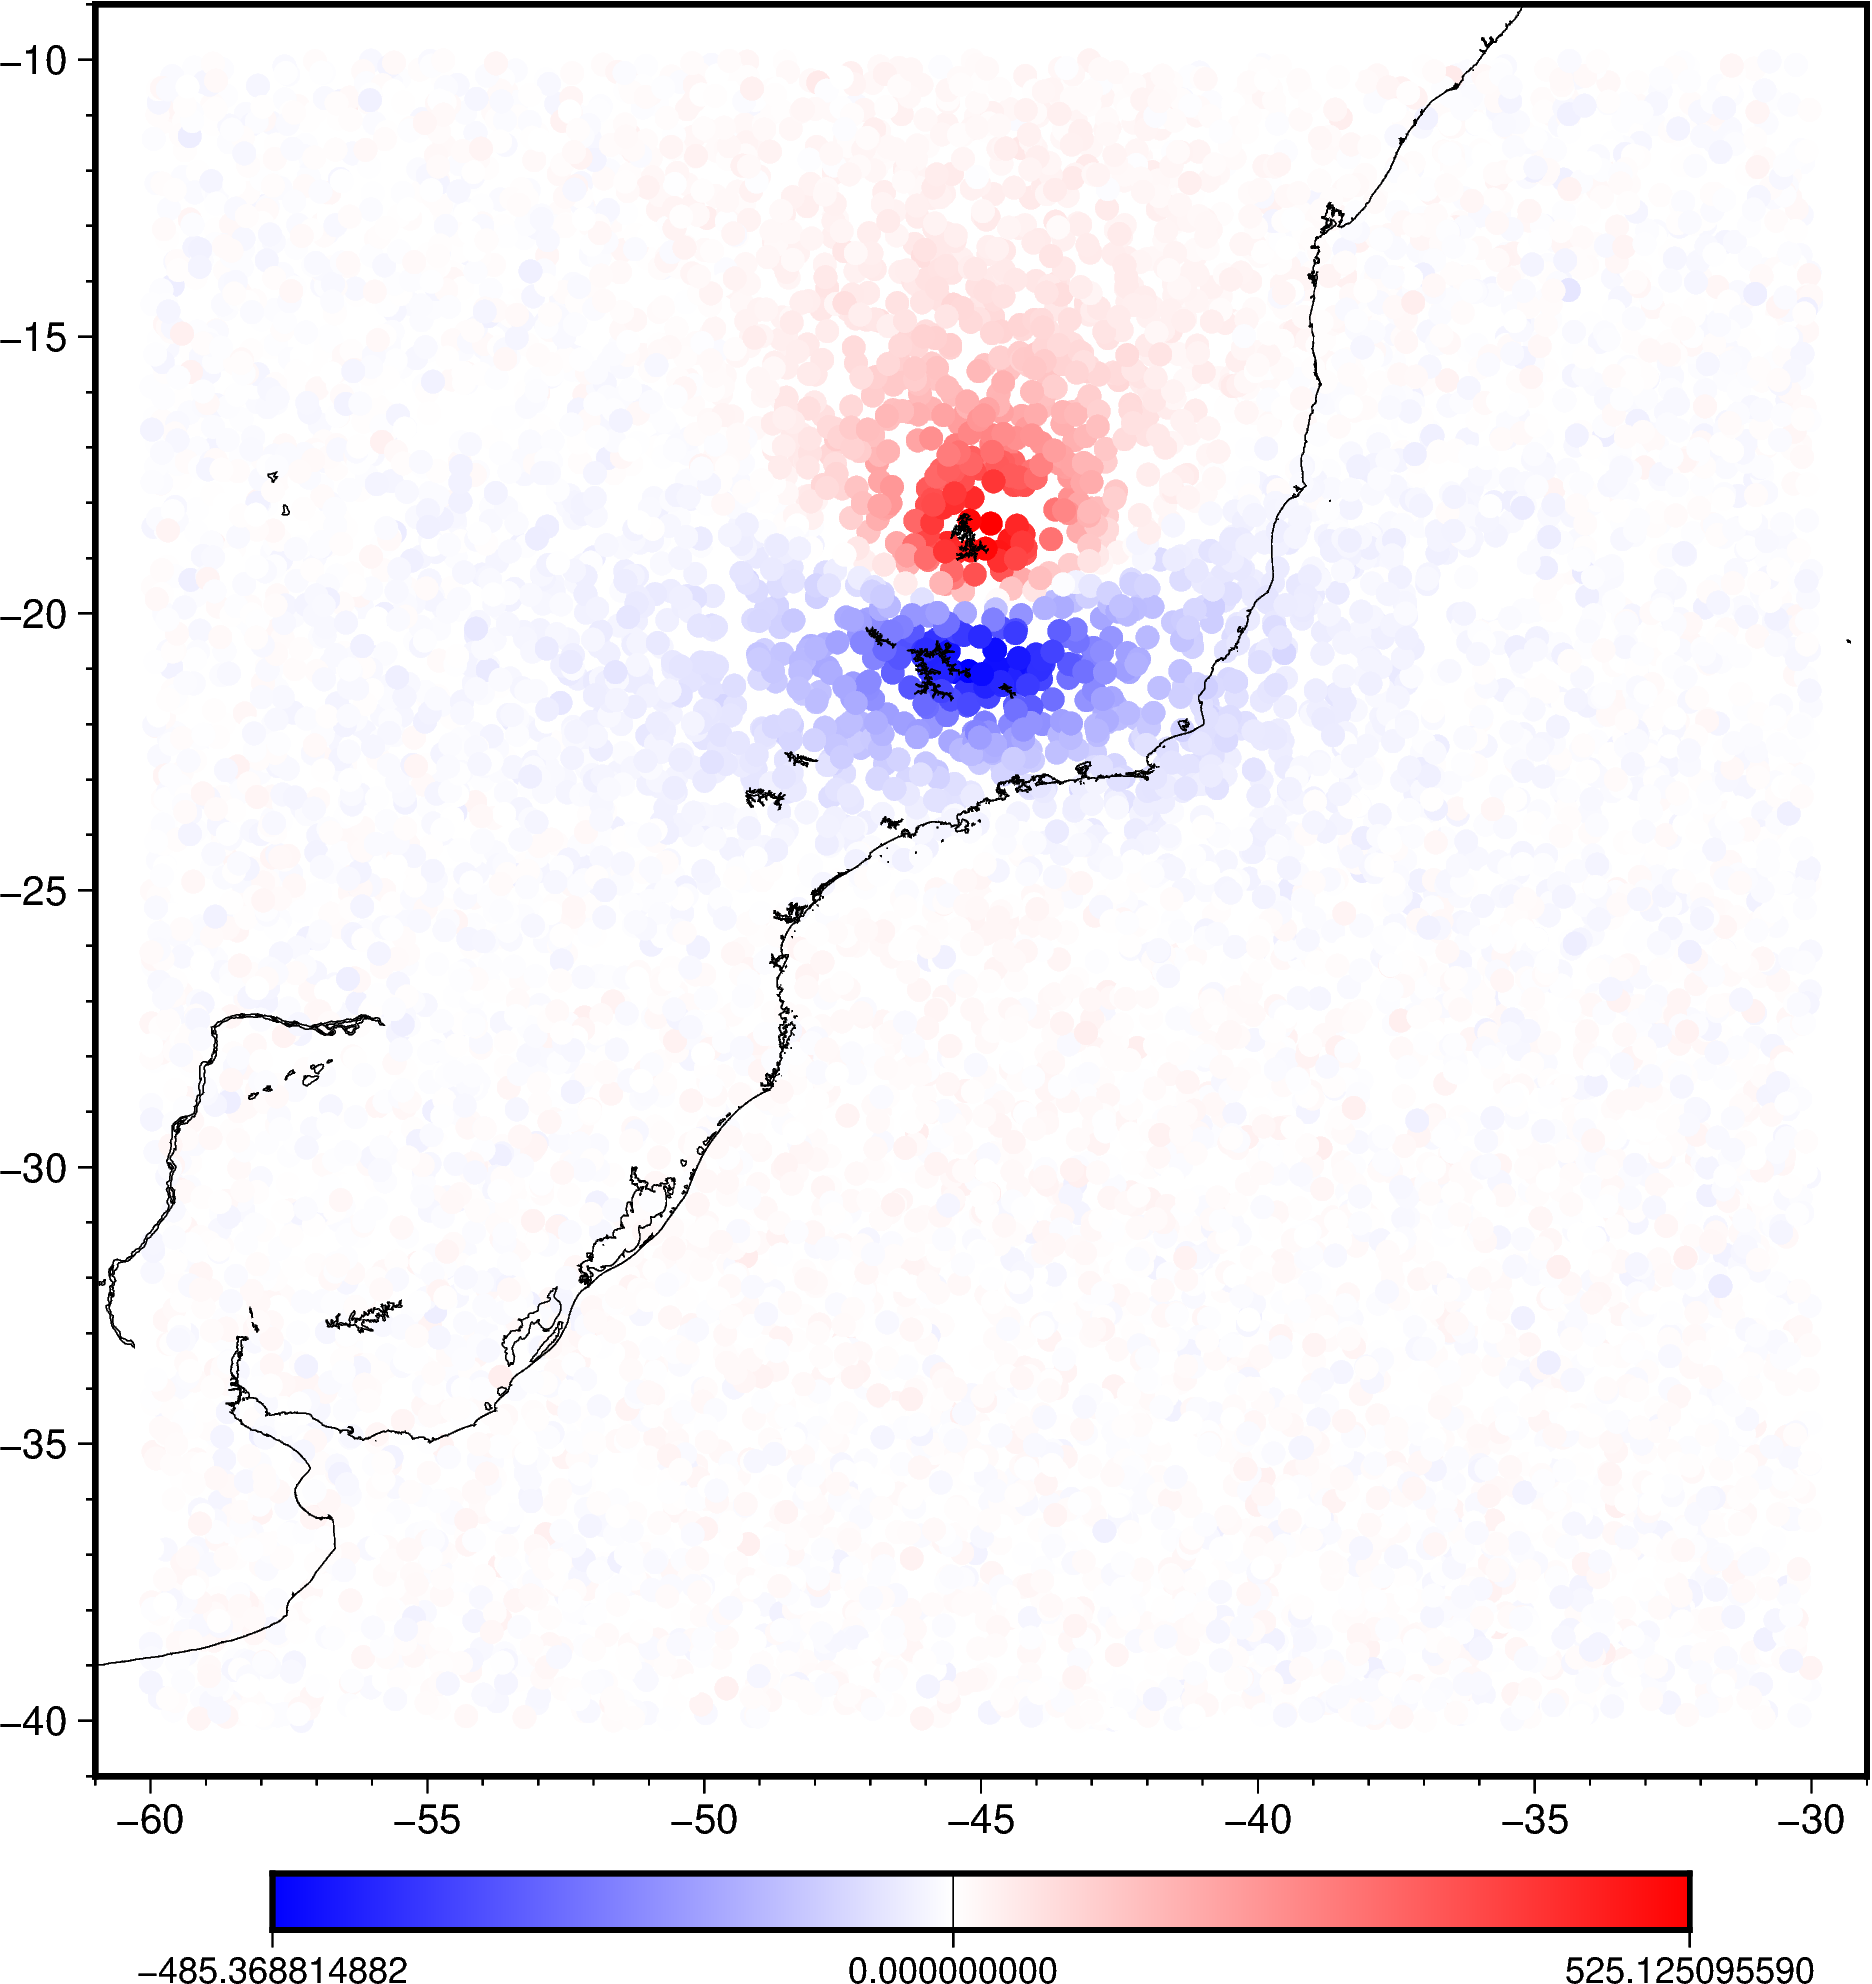

In [5]:
fig = pygmt.Figure()
pygmt.makecpt(cmap="polar+h", series=[data.min(), data.max()])
fig.plot(x=coordinates[0], y=coordinates[1], fill=data, style="c0.2c", cmap=True, frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Run the inversion.

In [6]:
%%time
eqs = sph.EquivalentSourcesMagGeod(damping=1e1, depth=100e3)
eqs.fit(coordinates, inclination, declination, data)

CPU times: user 2min 50s, sys: 5.94 s, total: 2min 56s
Wall time: 26 s


Calculate and plot the residuals.

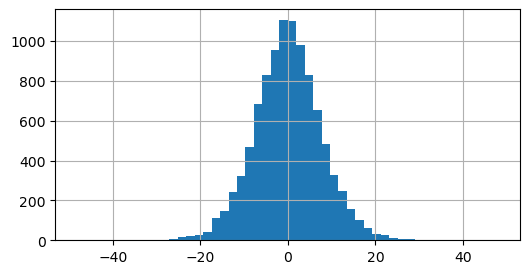

In [7]:
residuals = data - hm.total_field_anomaly(eqs.predict(coordinates), inclination, declination)
plt.figure(figsize=(6, 3))
plt.hist(residuals, bins=50)
plt.grid()
plt.show()

In [8]:
total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coordinates,
    hm.total_field_anomaly(eqs.predict(grid_coordinates), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

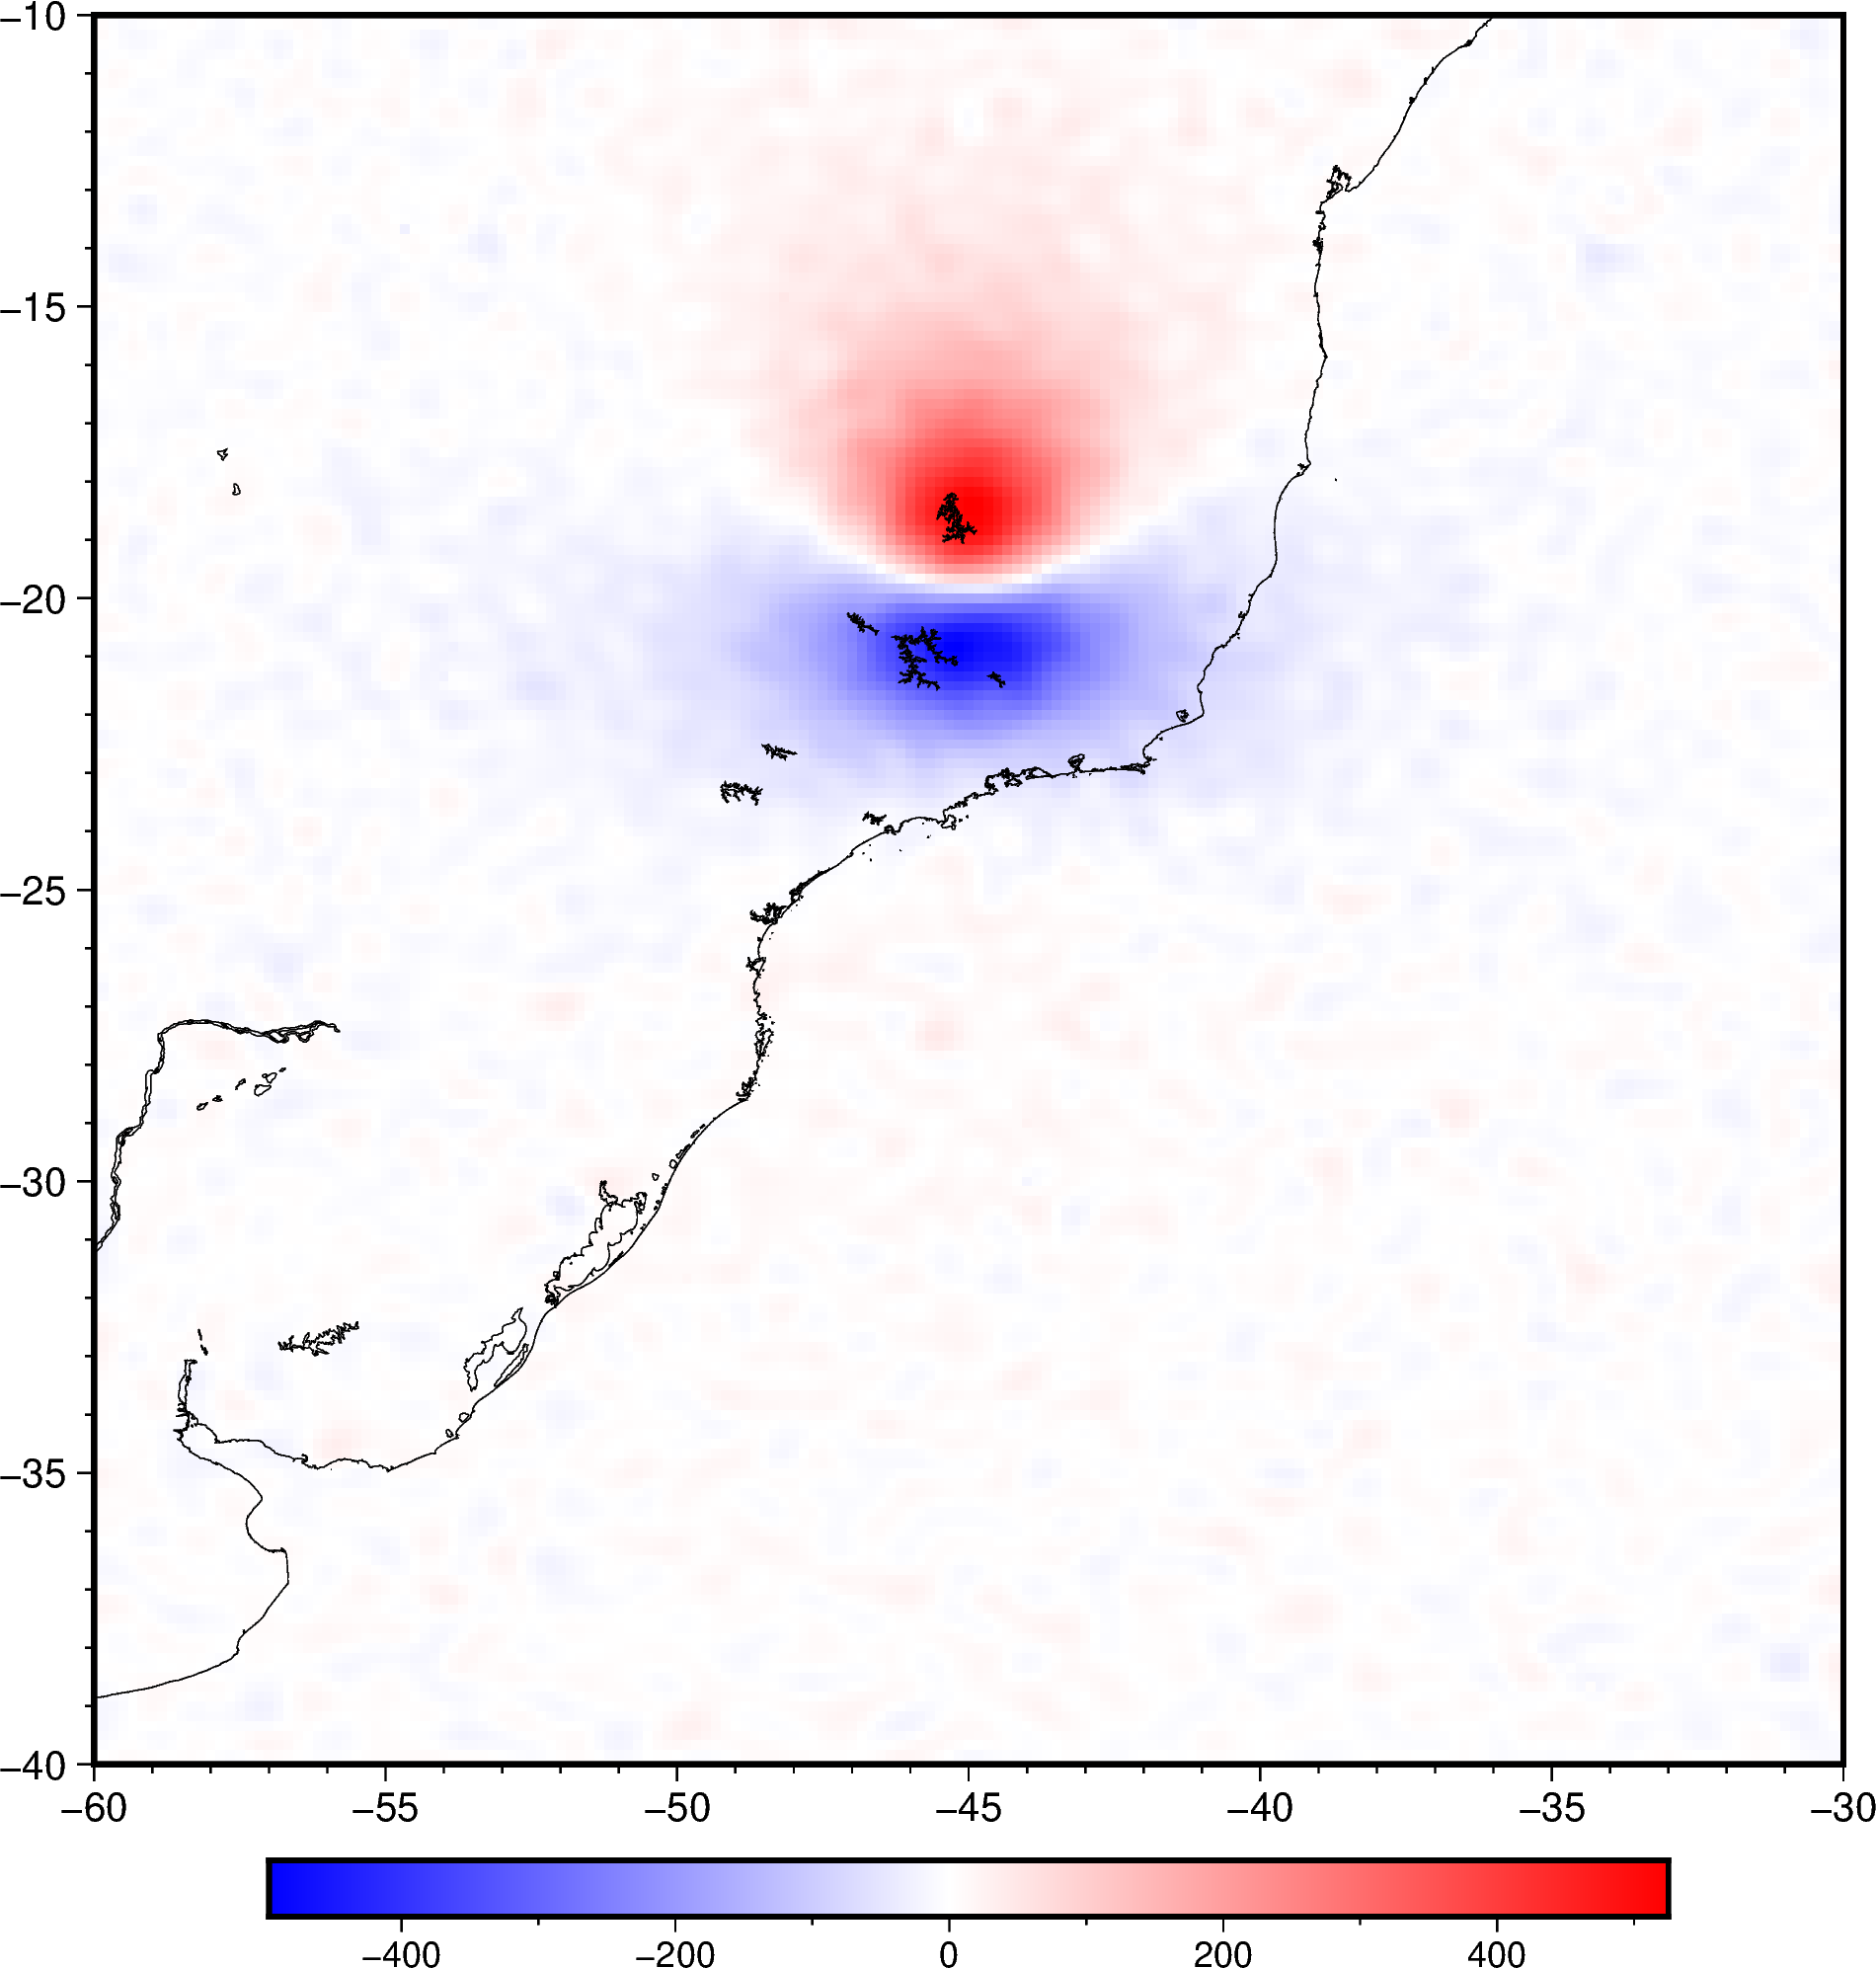

In [9]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Show the difference.

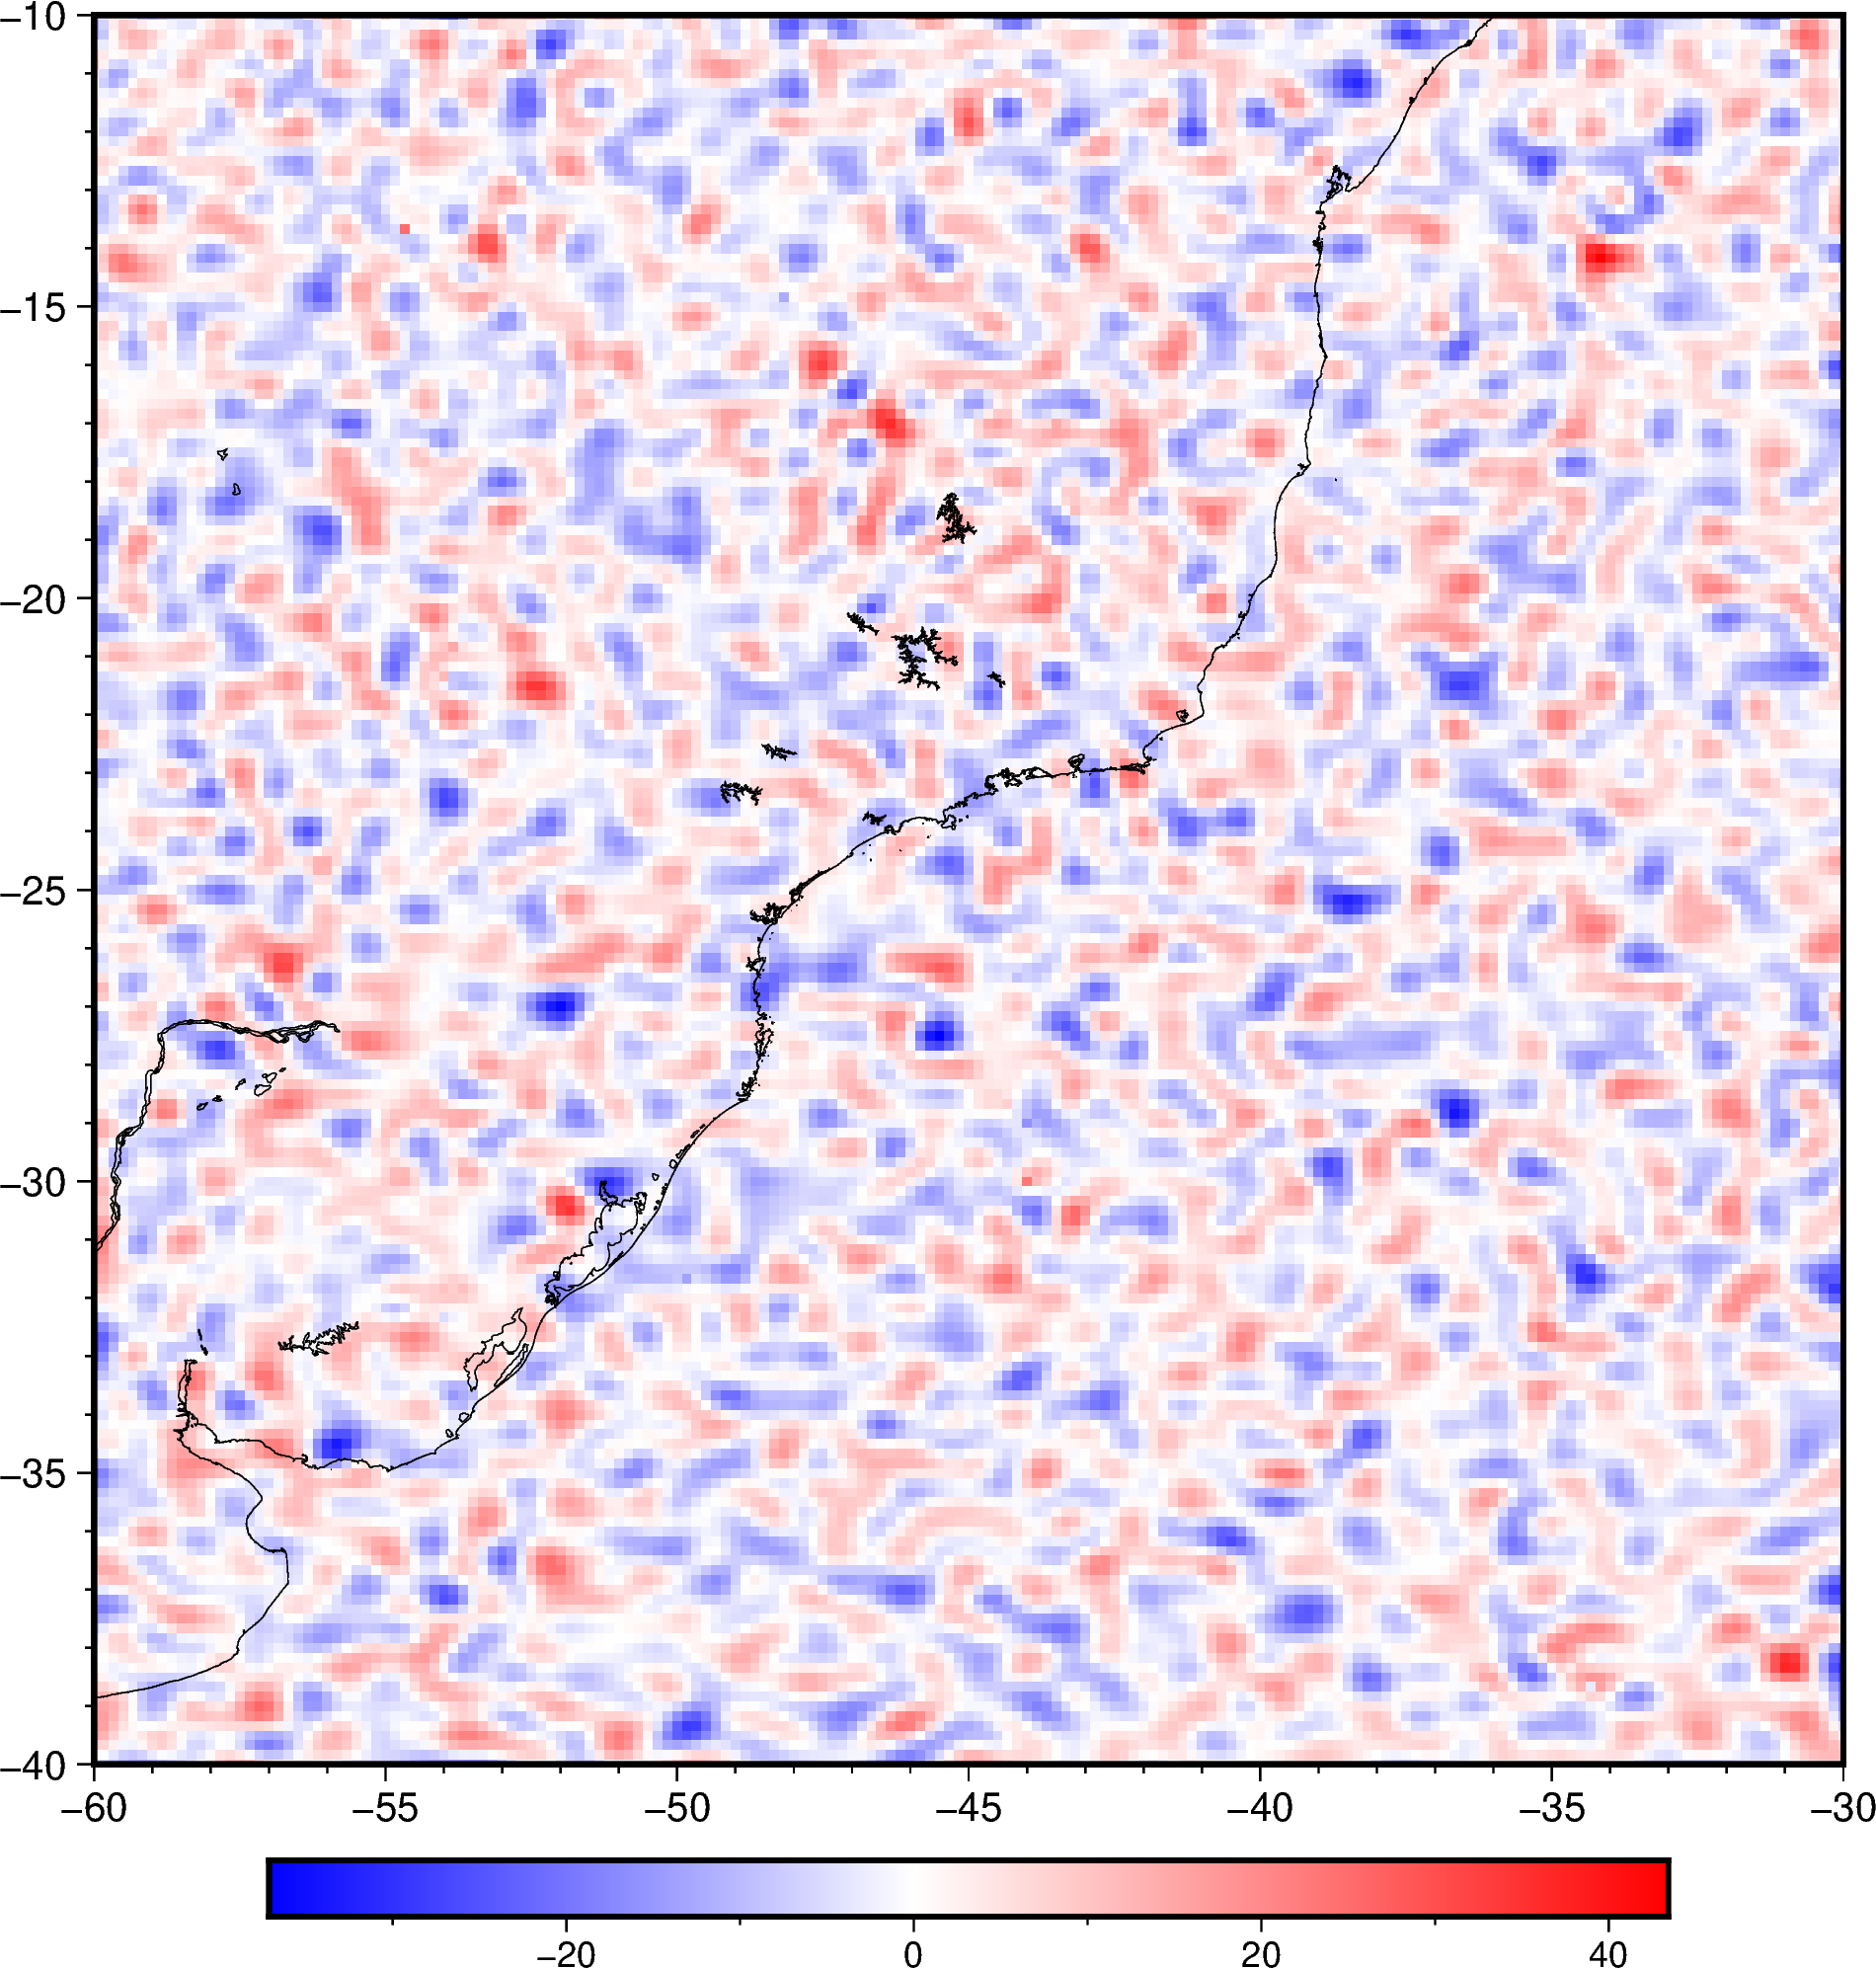

In [10]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly - total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

## Gradient-boosting

In [11]:
%%time
eqs = sph.EquivalentSourcesMagGeodGB(damping=1e1, depth=100e3, window_size=1000e3)
eqs.fit(coordinates, inclination, declination, data)
print(eqs.window_size_)

Output()

1000000.0
CPU times: user 1min 45s, sys: 535 ms, total: 1min 45s
Wall time: 15.7 s


Calculate and plot the residuals.

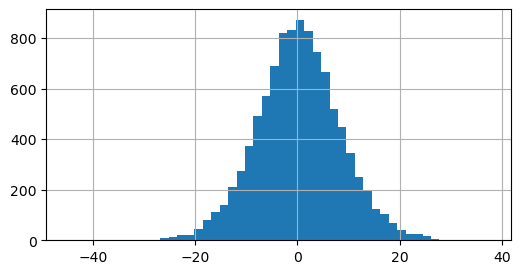

In [12]:
residuals = data - hm.total_field_anomaly(eqs.predict(coordinates), inclination, declination)
plt.figure(figsize=(6, 3))
plt.hist(residuals, bins=50)
plt.grid()
plt.show()

Predict on a grid.

In [13]:
total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coordinates,
    hm.total_field_anomaly(eqs.predict(grid_coordinates), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

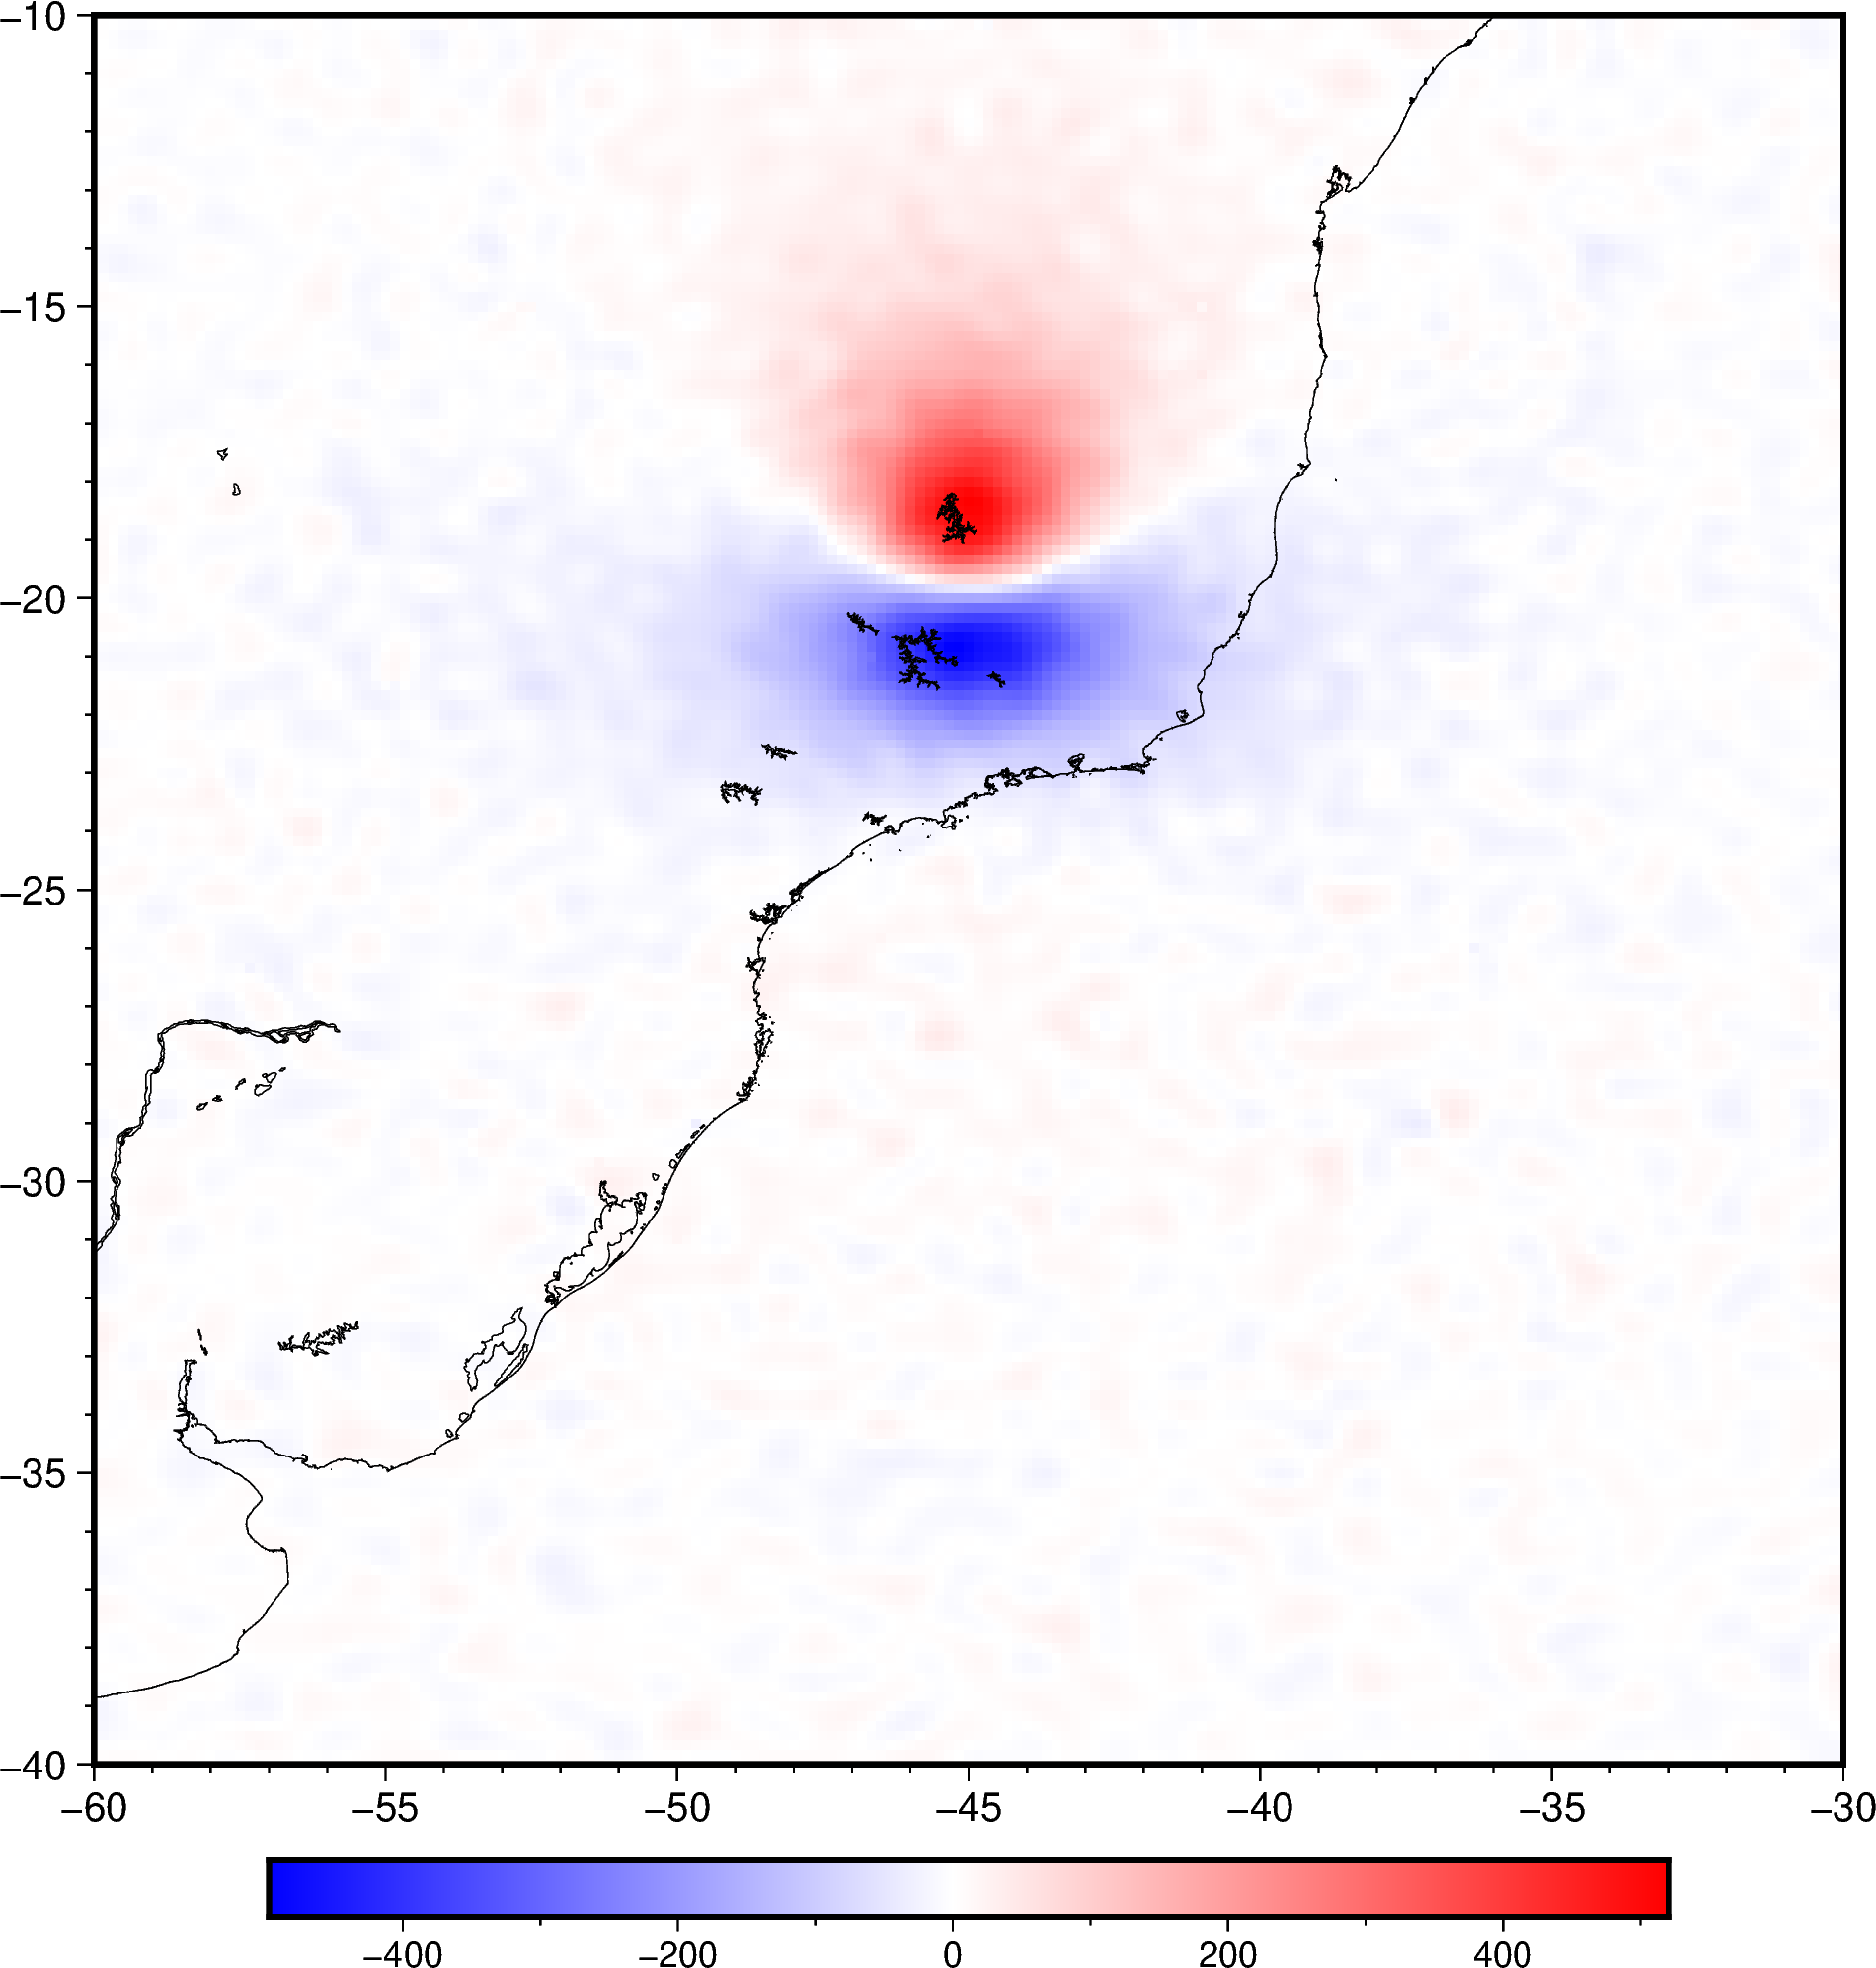

In [14]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Show the difference.

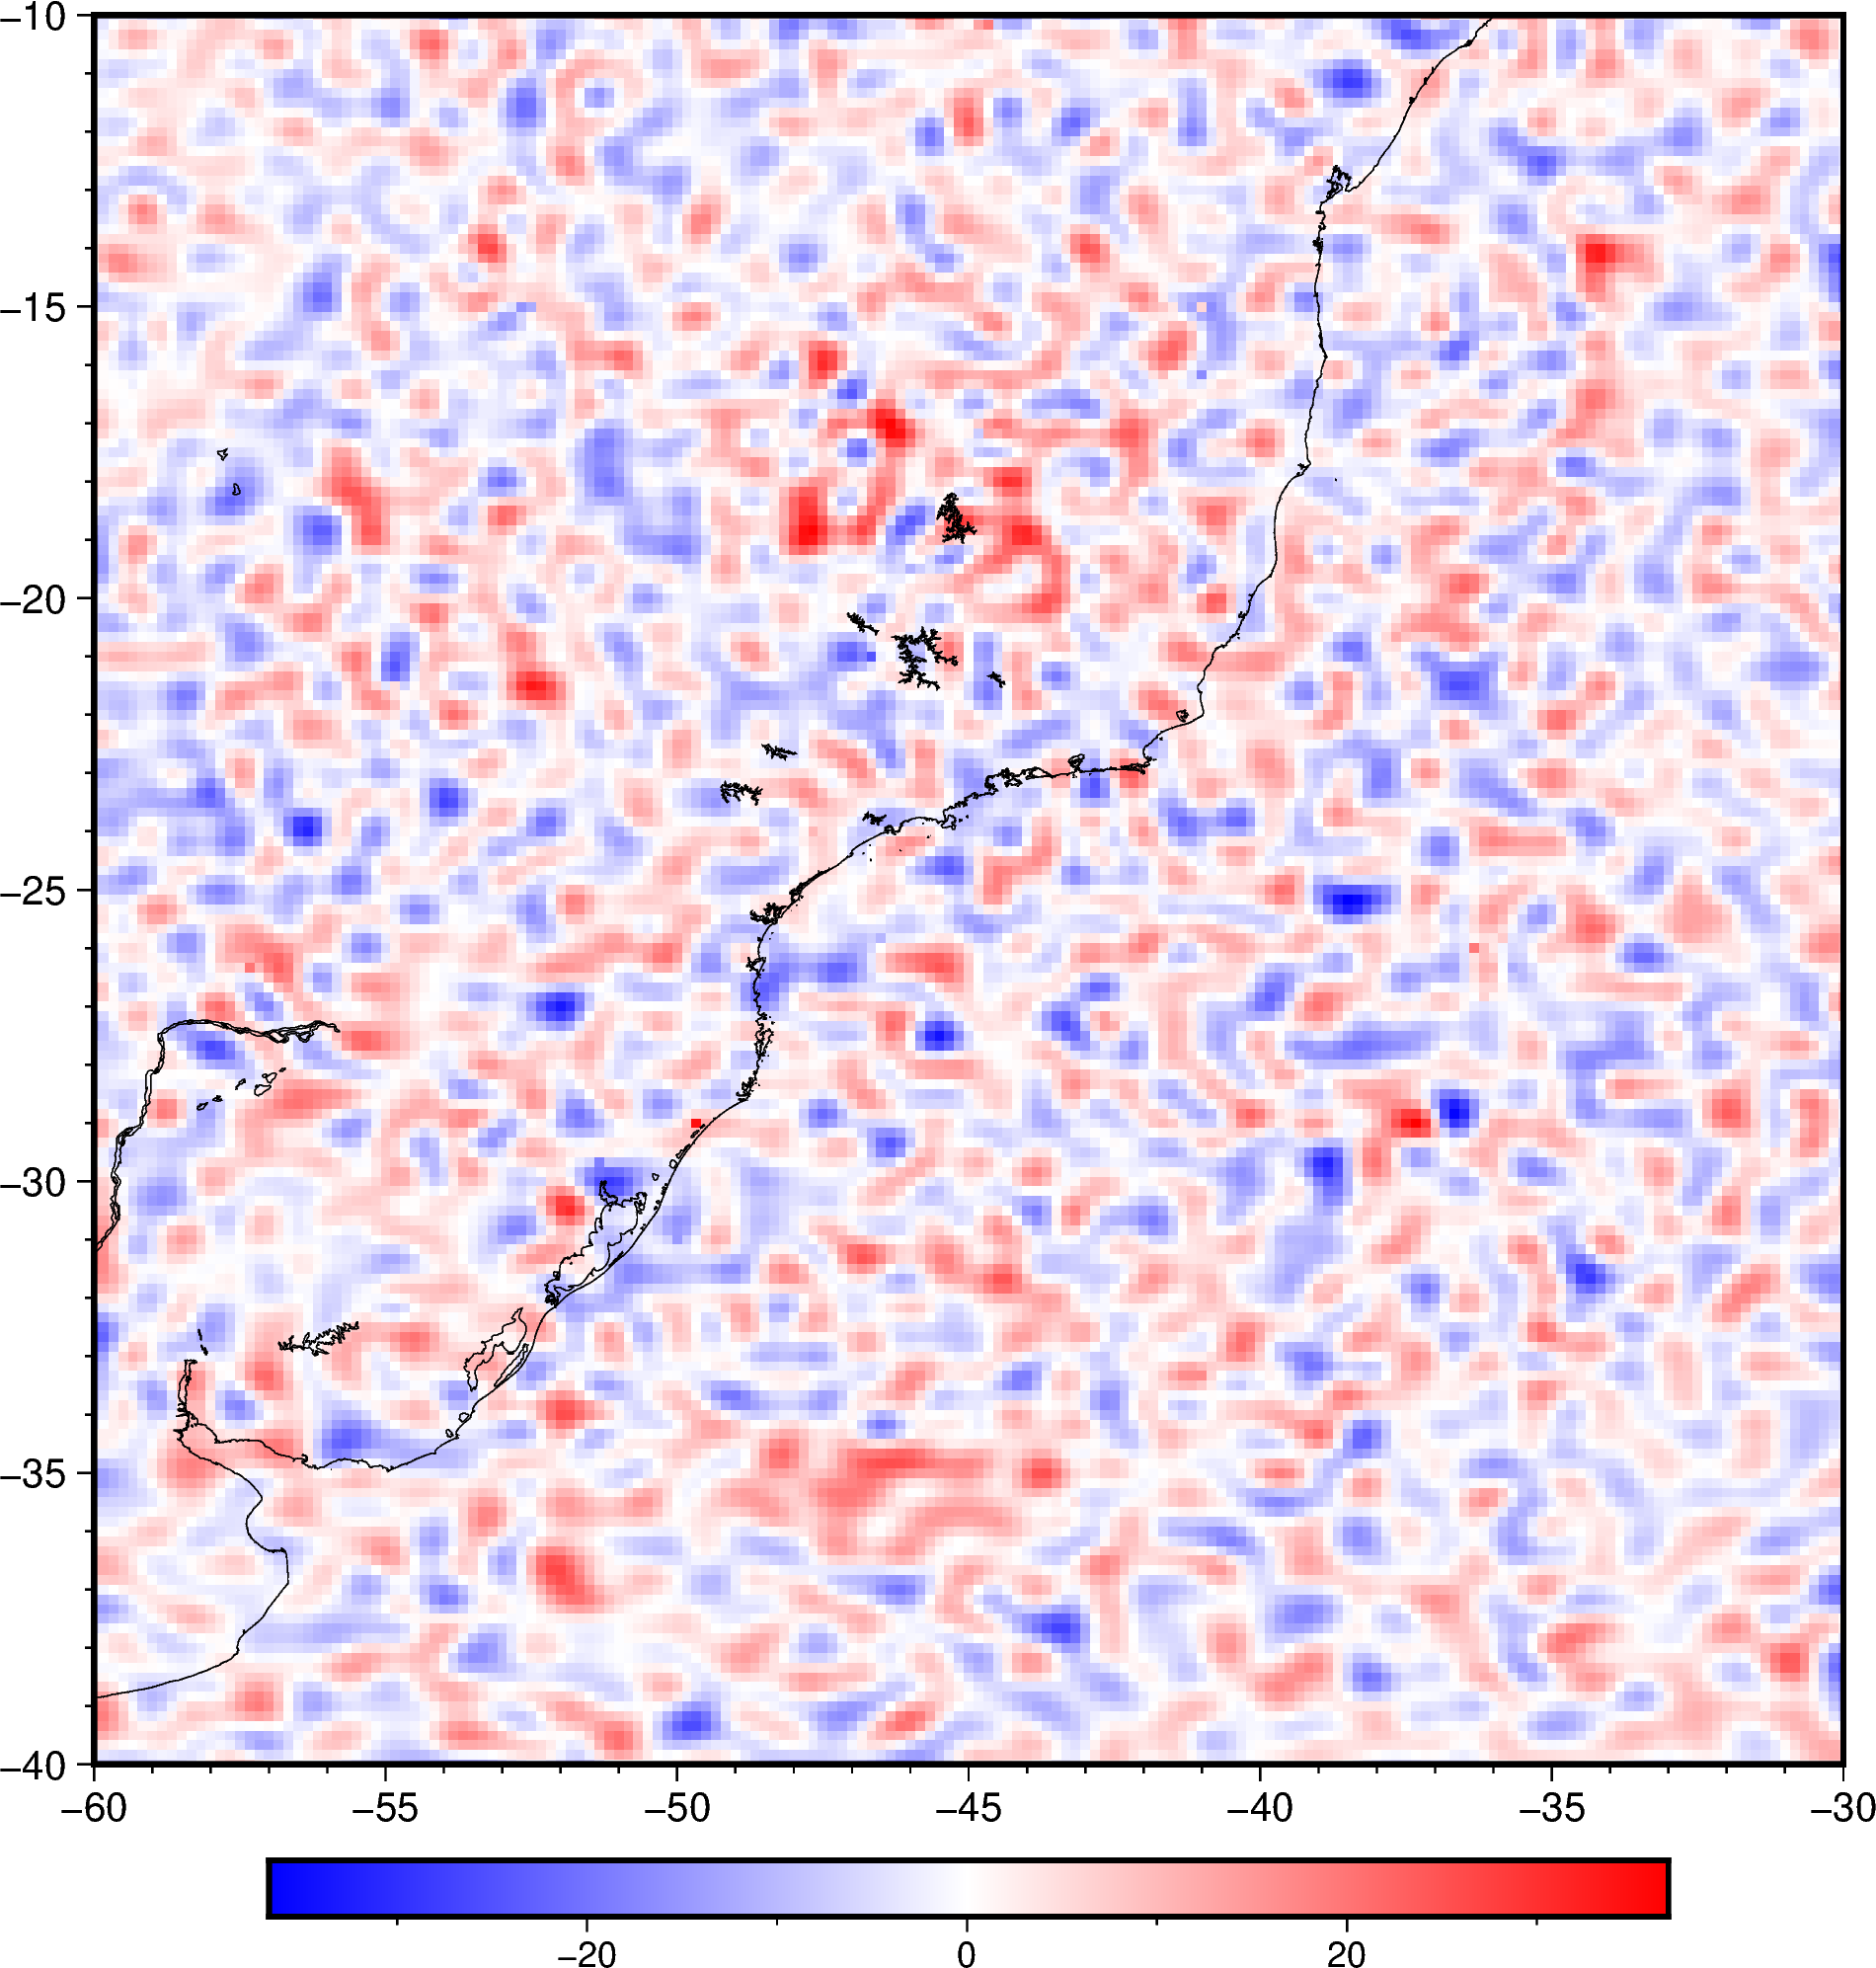

In [15]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly - total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

Plot the windows.

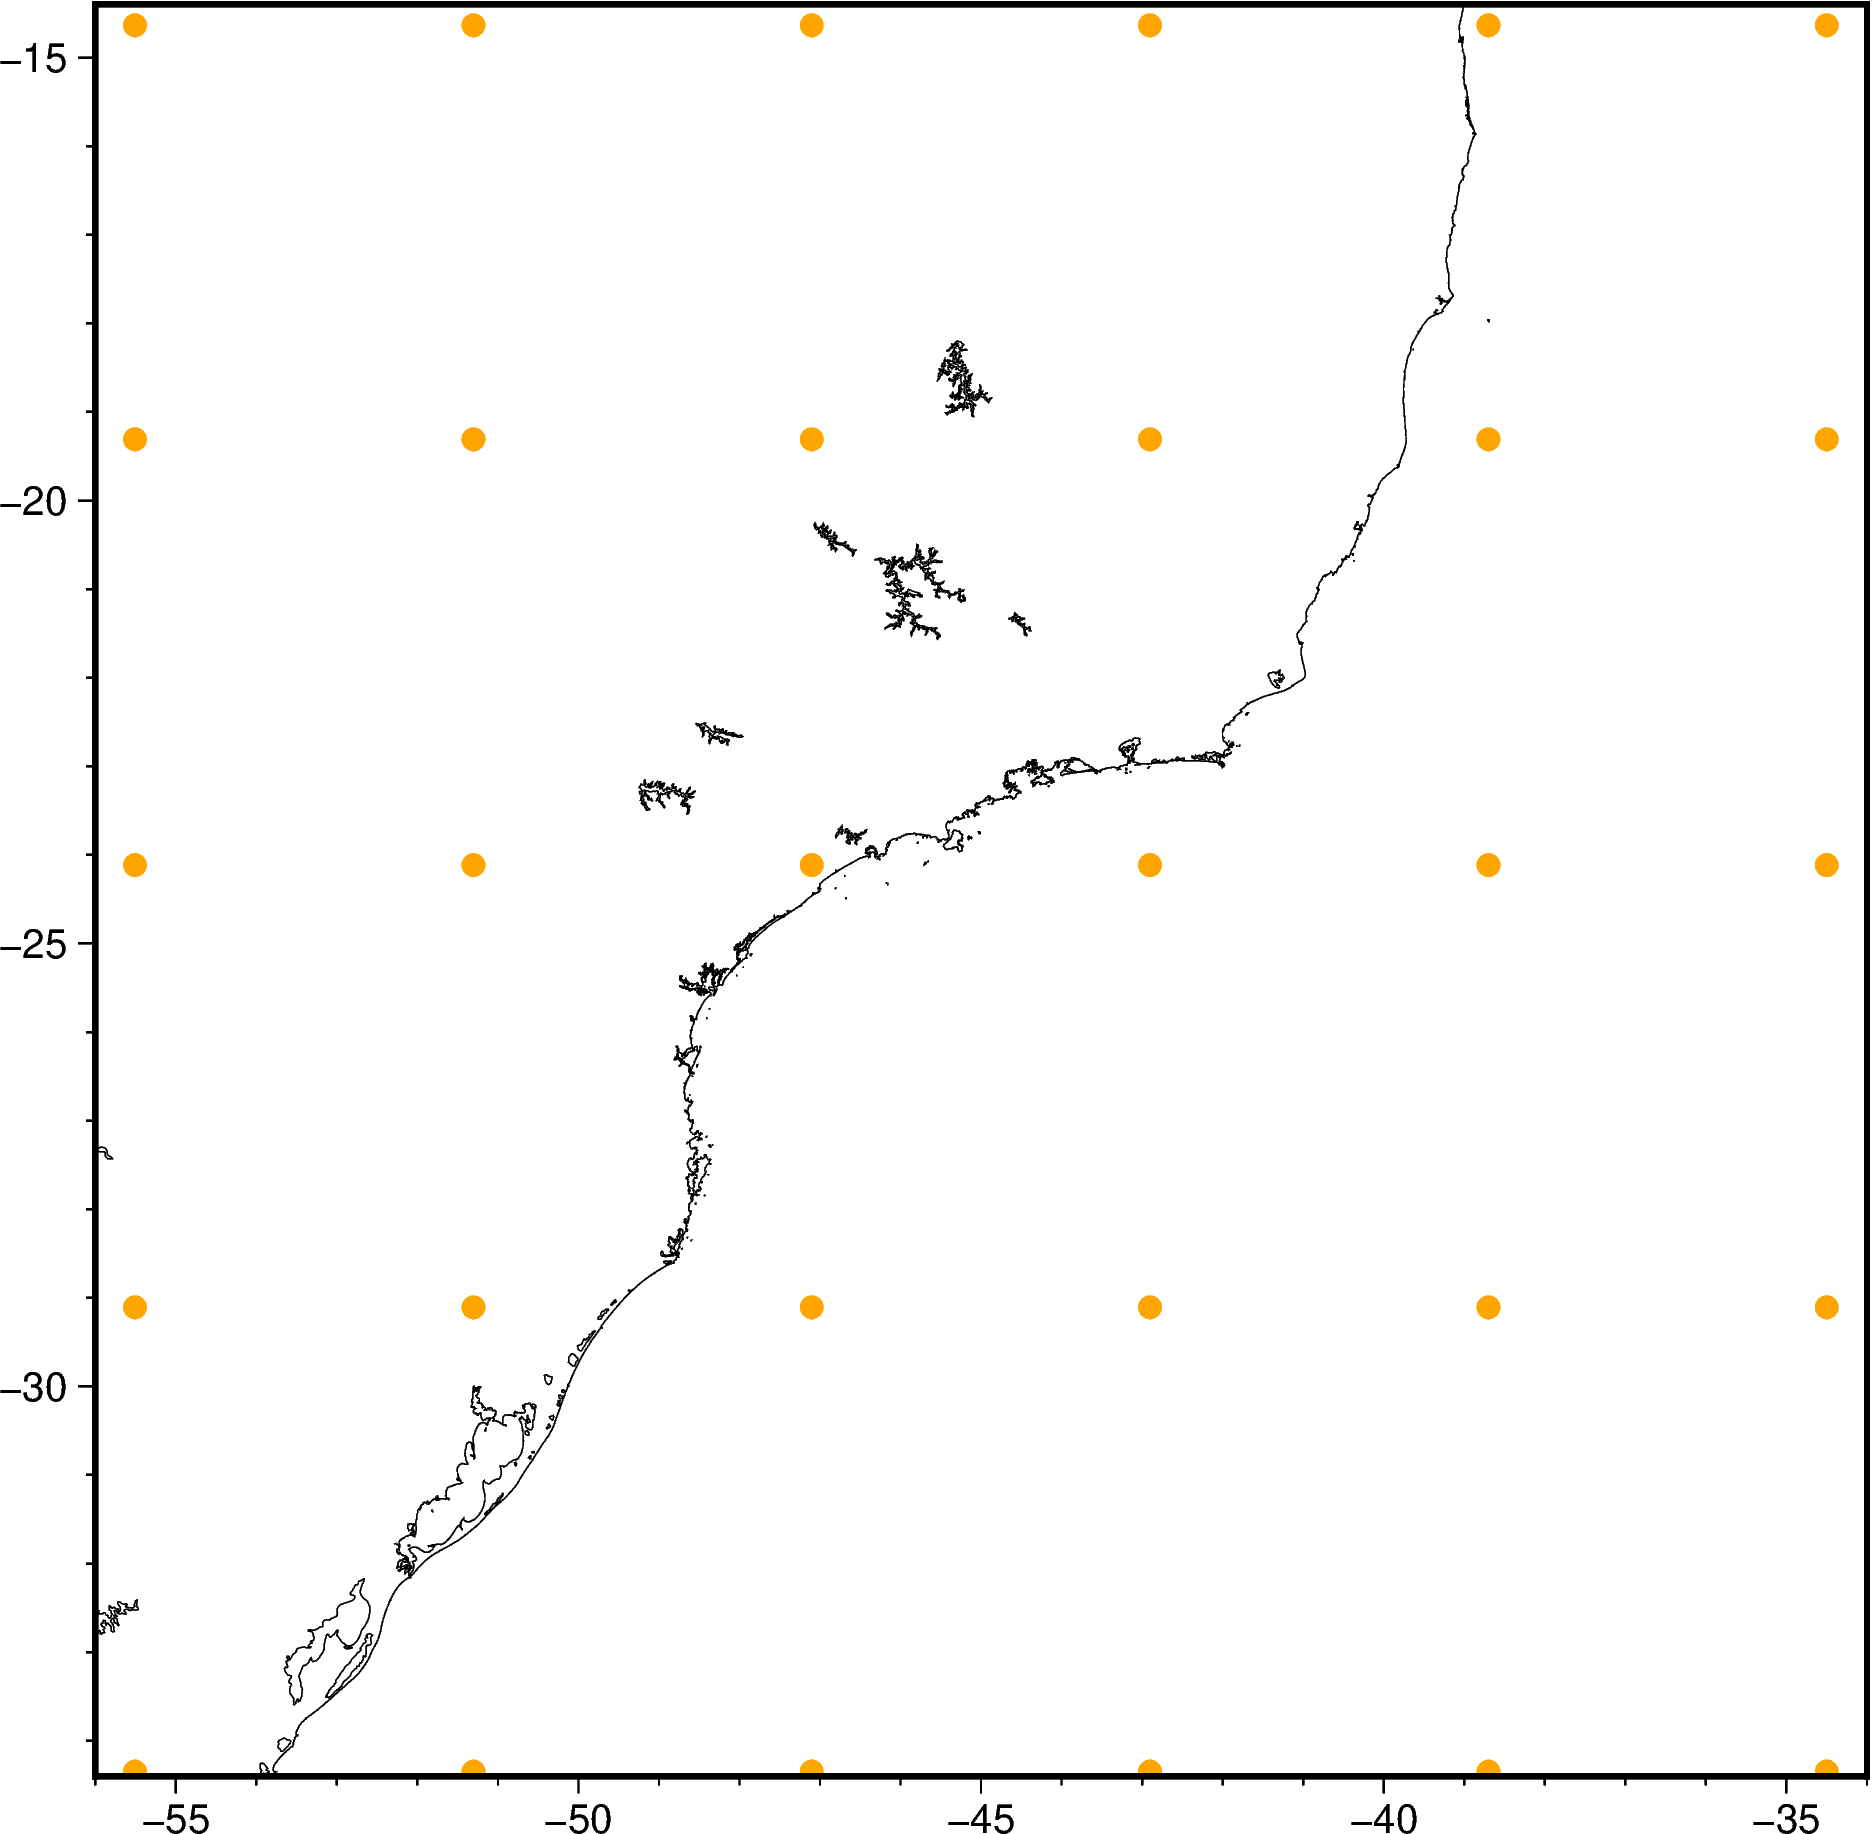

In [16]:
fig = pygmt.Figure()
fig.plot(x=eqs.window_centers_[0].ravel(), y=eqs.window_centers_[1].ravel(), fill="orange", style="c0.2c", frame=True)
fig.coast(shorelines=True)
fig.show()